<a href="https://colab.research.google.com/github/taniyayadav6263-byte/AI-Object-Detection-System/blob/main/AI_Object_Detection_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
print("Hello, Object Detection!")

Hello, Object Detection!


In [ ]:

!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 39.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 4.7 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

print("YOLO model loaded successfully!")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
YOLO model loaded successfully!


In [ ]:
from google.colab import files

uploaded = files.upload()


image 1/1 /content/IMG_20260204_233340_553.jpg: 640x288 1 person, 1 potted plant, 522.6ms
Speed: 28.2ms preprocess, 522.6ms inference, 62.7ms postprocess per image at shape (1, 3, 640, 288)


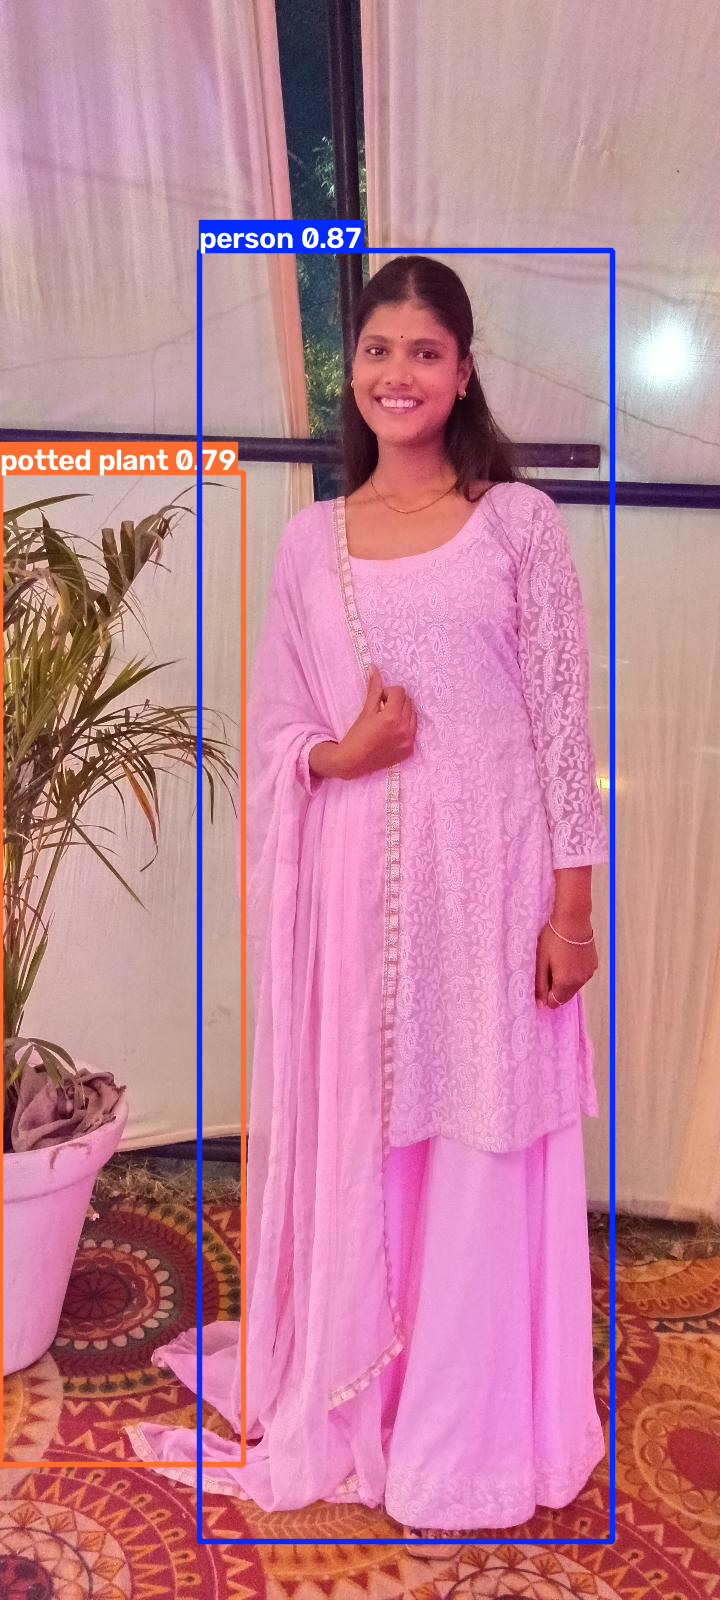

In [ ]:
results = model("IMG_20260204_233340_553.jpg")

results[0].show()

In [ ]:
result = results[0]

for box in result.boxes:
    class_id = int(box.cls[0])
    confidence = float(box.conf[0])
    object_name = result.names[class_id]

    print(f"Object: {object_name}")
    print(f"Confidence: {confidence * 100:.2f}%")
    print("-" * 30)

Object: person
Confidence: 86.81%
------------------------------
Object: potted plant
Confidence: 78.80%
------------------------------


In [ ]:
from collections import Counter

detected_objects = []

for box in results[0].boxes:
    class_id = int(box.cls[0])
    object_name = results[0].names[class_id]
    detected_objects.append(object_name)

counts = Counter(detected_objects)

print("Detected Objects:")
for obj, count in counts.items():
    print(f"{obj}: {count}")

Detected Objects:
person: 1
potted plant: 1


In [ ]:
results = model("IMG_20260204_233340_553.jpg")

results[0].save(filename="detected_result.jpg")

print("Detected image saved successfully!")


image 1/1 /content/IMG_20260204_233340_553.jpg: 640x288 1 person, 1 potted plant, 166.6ms
Speed: 6.6ms preprocess, 166.6ms inference, 2.9ms postprocess per image at shape (1, 3, 640, 288)
Detected image saved successfully!


In [ ]:
!pip install gradio -q

In [ ]:
import gradio as gr

print("Gradio is ready!")

Gradio is ready!


In [ ]:
import gradio as gr

def detect_objects(image):
    results = model(image)

    result = results[0]

    # Detection image
    output_image = result.plot()

    # Object details
    detected = []

    for box in result.boxes:
        class_id = int(box.cls[0])
        confidence = float(box.conf[0])
        object_name = result.names[class_id]

        detected.append(
            f"{object_name} — {confidence * 100:.2f}%"
        )

    if detected:
        details = "\n".join(detected)
    else:
        details = "No objects detected."

    return output_image, details


app = gr.Interface(
    fn=detect_objects,
    inputs=gr.Image(type="numpy", label="Upload Image"),
    outputs=[
        gr.Image(label="Detection Result"),
        gr.Textbox(label="Detected Objects")
    ],
    title="AI Object Detection System",
    description="Upload an image and detect objects using YOLO."
)

app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://43e9c64b28034740dc.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [15]:
from collections import Counter
import gradio as gr

def detect_objects(image):
    results = model(image)
    result = results[0]

    # Detection image
    output_image = result.plot()

    # Object names
    detected_objects = []

    for box in result.boxes:
        class_id = int(box.cls[0])
        detected_objects.append(result.names[class_id])

    # Count objects
    counts = Counter(detected_objects)

    if counts:
        details = f"Total Objects Detected: {len(detected_objects)}\n\n"

        for obj, count in counts.items():
            details += f"• {obj}: {count}\n"
    else:
        details = "No objects detected."

    return output_image, details


app = gr.Interface(
    fn=detect_objects,
    inputs=gr.Image(type="numpy", label="📷 Upload Image"),
    outputs=[
        gr.Image(label="🔍 Detection Result"),
        gr.Textbox(label="📊 Detection Summary")
    ],
    title="🤖 AI Object Detection System",
    description="Upload an image to detect and count objects using YOLO.",
    submit_btn="🔍 Detect Objects",
    clear_btn="🗑️ Clear"
)

app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://90afbf920ab4436a51.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [16]:
from collections import Counter
import gradio as gr

def detect_objects(image):
    results = model(image)
    result = results[0]

    output_image = result.plot()

    objects = []

    for box in result.boxes:
        class_id = int(box.cls[0])
        confidence = float(box.conf[0])
        name = result.names[class_id]

        objects.append((name, confidence))

    counts = Counter(name for name, confidence in objects)

    if objects:
        details = f"Total Objects: {len(objects)}\n\n"

        for name, count in counts.items():
            details += f"• {name}: {count}\n"

        details += "\nConfidence:\n"

        for name, confidence in objects:
            details += f"• {name}: {confidence * 100:.2f}%\n"
    else:
        details = "No objects detected."

    return output_image, details


app = gr.Interface(
    fn=detect_objects,
    inputs=gr.Image(type="numpy", label="📷 Upload Image"),
    outputs=[
        gr.Image(label="🔍 Detection Result"),
        gr.Textbox(label="📊 Detection Summary")
    ],
    title="🤖 AI Object Detection System",
    description="Detect, count and identify objects using YOLO.",
    submit_btn="🔍 Detect Objects",
    clear_btn="🗑️ Clear"
)

app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://54410e48aaca25bf32.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [17]:
import gradio as gr

def detect_objects(image):
    results = model(image)
    result = results[0]

    output_image = result.plot()

    objects = []

    for box in result.boxes:
        class_id = int(box.cls[0])
        confidence = float(box.conf[0])
        name = result.names[class_id]
        objects.append((name, confidence))

    if not objects:
        return output_image, "No objects detected."

    from collections import Counter
    counts = Counter(name for name, confidence in objects)

    summary = f"### Total Objects: {len(objects)}\n\n"

    for name, count in counts.items():
        summary += f"**{name}**: {count} object(s)  \n"

    summary += "\n### Confidence Scores\n\n"

    for name, confidence in objects:
        summary += f"**{name}**: {confidence * 100:.2f}%  \n"

    return output_image, summary


with gr.Blocks(title="AI Object Detection System") as app:

    gr.Markdown("""
    # 🤖 AI Object Detection System
    ### Detect • Identify • Count Objects using YOLO
    """)

    with gr.Row():

        with gr.Column():
            image_input = gr.Image(
                type="numpy",
                label="📷 Upload Image"
            )

            detect_button = gr.Button(
                "🔍 Detect Objects"
            )

        with gr.Column():
            output_image = gr.Image(
                label="Detection Result"
            )

            output_text = gr.Markdown(
                label="Detection Summary"
            )

    detect_button.click(
        fn=detect_objects,
        inputs=image_input,
        outputs=[output_image, output_text]
    )

app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ac0a699aa56c21a7e5.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [18]:

import gradio as gr

def detect_objects(image):
    results = model(image)
    return results[0].plot()

with gr.Blocks() as app:

    gr.Markdown("""
    # 🤖 AI Object Detection System
    ### Real-Time Object Detection using YOLO
    """)

    camera = gr.Image(
        sources=["webcam"],
        type="numpy",
        label="📷 Camera"
    )

    output = gr.Image(
        label="🔍 Detection Result"
    )

    detect_button = gr.Button("🔍 Detect")

    detect_button.click(
        fn=detect_objects,
        inputs=camera,
        outputs=output
    )

app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://eb1ddefc57b96674c6.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
